# Agente Experto en analizar económicamente el sector de la industria textil y la moda en España
**Stack:** Google Gemini · ChromaDB · LangGraph · RAG + Memoria  
**Dominio:** Industria textil y moda en España (5 documentos PDF)

---
## PASO 1 — Carga y preprocesamiento de documentos PDF

#### Imports y configuración inicial

In [1]:
import os
import gc
import chromadb
import time
import google.generativeai as genai
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

load_dotenv(dotenv_path=Path("..") / ".env")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

C:\Users\vicho\AppData\Local\Temp\ipykernel_18668\2116857348.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
DOCS_DIR = Path("..") / "docs"

pdf_files = [
    DOCS_DIR / "informe-economico-de-la-moda-en-espana-2025.pdf",
    DOCS_DIR / "presentaciones_sectoriales_textil.pdf",
    DOCS_DIR / "memoria_anual_inditex_2025.pdf",
    DOCS_DIR / "comercio_textil_2024.pdf",
]

documents = []
for path in pdf_files:
    if not path.exists():
        print(f"⚠ No encontrado: {path}")
        continue
    loader = PyPDFLoader(str(path))
    docs = loader.load()
    documents.extend(docs)
    print(f"✓ {path.name:<55} {len(docs):>3} páginas")

print(f"\nTotal páginas cargadas: {len(documents)}")

✓ informe-economico-de-la-moda-en-espana-2025.pdf         134 páginas
✓ presentaciones_sectoriales_textil.pdf                    36 páginas
✓ memoria_anual_inditex_2025.pdf                           85 páginas
✓ comercio_textil_2024.pdf                                 67 páginas

Total páginas cargadas: 322


##### Chunking con RecursiveCharacterTextSplitter

In [3]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(documents)

print(f"Total chunks generados:    {len(chunks)}")
print(f"Promedio chars/chunk:      {sum(len(c.page_content) for c in chunks) // len(chunks)}")

print("\n=== Ejemplo chunk #20 ===")
print(f"Fuente: {Path(chunks[20].metadata.get('source', 'N/A')).name} | Página: {chunks[20].metadata.get('page', 'N/A')}")
print(chunks[20].page_content)

Total chunks generados:    681
Promedio chars/chunk:      731

=== Ejemplo chunk #20 ===
Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | Página: 8
y la identidad local. España tiene talento 
creativo, capacidad industrial, compañías 
internacionales y una cultura empresarial 
resiliente. Pero necesita seguir escalando, 
especializarse y diferenciarse todavía más.
Debemos avanzar hacia un modelo más 
circular, innovador, tecnológico y conectado 
con clientes, usuarios y consumidores, que 
combine diseño, ecodiseño, trazabilidad y 
valor añadido. Una Industria que sepa com-
petir en nichos globales y que, sin perder 
su arraigo territorial, sepa colaborar más 
allá de fronteras sin diluir su autenticidad.
El futuro de la Industria del textil y 
moda española debe estar en el liderazgo eu-
ropeo en calidad, innovación, sostenibilidad 
y responsabilidad social, la construcción de 
cadenas de valor glocales, y la capacidad de 
inspirar al mundo desde nuestras fortalezas. 
No se tr

##### Diagnóstico de modelos disponibles para embeddings

In [4]:
import google.generativeai as genai

genai.configure(api_key=GOOGLE_API_KEY)

print("Modelos de embedding disponibles en tu cuenta:\n")
for m in genai.list_models():
    if "embed" in m.name.lower() or "embed" in m.supported_generation_methods[0].lower() if m.supported_generation_methods else False:
        print(f"  Nombre: {m.name}")
        print(f"  Métodos: {m.supported_generation_methods}\n")

Modelos de embedding disponibles en tu cuenta:

  Nombre: models/gemini-embedding-001
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2-preview
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']



##### Crear embeddings con HuggingFace e indexar en ChromaDB

In [5]:
EMBEDDING_MODEL = "models/gemini-embedding-001"
CHROMA_DIR      = str(Path("..") / "chroma_db")
COLLECTION_NAME = "textil_moda_espana"

# --- Eliminar colección anterior ---
if Path(CHROMA_DIR).exists():
    try:
        _tmp = chromadb.PersistentClient(path=CHROMA_DIR)
        _tmp.delete_collection(COLLECTION_NAME)
        del _tmp
        gc.collect()
        print("✓ Colección anterior eliminada")
    except Exception:
        pass

# --- Gemini Embeddings ---
embeddings = GoogleGenerativeAIEmbeddings(
    model=EMBEDDING_MODEL,
    google_api_key=GOOGLE_API_KEY,
)

# --- Indexado por lotes con pausa para respetar el límite del free tier ---
BATCH_SIZE = 50        # chunks por lote (bien por debajo del límite de 100/min)
PAUSA_SEGUNDOS = 20    # pausa entre lotes

print(f"Total chunks a indexar: {len(chunks)}")
print(f"Lotes de {BATCH_SIZE} chunks con {PAUSA_SEGUNDOS}s de pausa entre lotes")
print(f"Tiempo estimado: ~{((len(chunks) // BATCH_SIZE) * PAUSA_SEGUNDOS) // 60} minutos\n")

vectorstore = None

for i in range(0, len(chunks), BATCH_SIZE):
    lote = chunks[i:i + BATCH_SIZE]
    lote_num = (i // BATCH_SIZE) + 1
    total_lotes = (len(chunks) + BATCH_SIZE - 1) // BATCH_SIZE

    print(f"  Lote {lote_num}/{total_lotes} — chunks {i} a {i + len(lote) - 1}...", end=" ")

    try:
        if vectorstore is None:
            vectorstore = Chroma.from_documents(
                documents=lote,
                embedding=embeddings,
                collection_name=COLLECTION_NAME,
                persist_directory=CHROMA_DIR,
            )
        else:
            vectorstore.add_documents(lote)

        print("✓")

    except Exception as e:
        print(f"\n  ⚠ Error en lote {lote_num}: {e}")
        print("  Esperando 30s antes de reintentar...")
        time.sleep(30)
        try:
            vectorstore.add_documents(lote)
            print(f"  ✓ Lote {lote_num} reintentado con éxito")
        except Exception as e2:
            print(f"  ✗ Fallo definitivo en lote {lote_num}: {e2}")

    # Pausa entre lotes (excepto después del último)
    if i + BATCH_SIZE < len(chunks):
        time.sleep(PAUSA_SEGUNDOS)

total = vectorstore._collection.count()
print(f"\n✓ Colección '{COLLECTION_NAME}' creada con Gemini Embeddings")
print(f"✓ Chunks indexados: {total}")
print(f"✓ Persistido en:    {CHROMA_DIR}")

Total chunks a indexar: 681
Lotes de 50 chunks con 20s de pausa entre lotes
Tiempo estimado: ~4 minutos

  Lote 1/14 — chunks 0 a 49... ✓
  Lote 2/14 — chunks 50 a 99... 
  ⚠ Error en lote 2: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. ', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}]}}
  Esperando 30s antes de reintentar...
  ✗ Fallo definitivo en lote 2: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and 

In [5]:
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
CHROMA_DIR = str(Path("..") / "chroma_db")
COLLECTION_NAME = "textil_moda_espana"

# Eliminar colección anterior para evitar duplicados al re-ejecutar
if Path(CHROMA_DIR).exists():
    try:
        _tmp = chromadb.PersistentClient(path=CHROMA_DIR)
        _tmp.delete_collection(COLLECTION_NAME)
        del _tmp
        gc.collect()
        print("✓ Colección anterior eliminada")
    except Exception:
        pass

print(f"Cargando embeddings: {EMBEDDING_MODEL}\n")
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

print(f"Indexando {len(chunks)} chunks en ChromaDB...\n")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=CHROMA_DIR,
)

total = vectorstore._collection.count()
print(f"✓ Colección '{COLLECTION_NAME}' creada ({EMBEDDING_MODEL})")
print(f"✓ Chunks indexados: {total}")
print(f"✓ Persistido en:    {CHROMA_DIR}")

Cargando embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexando 937 chunks en ChromaDB...

✓ Colección 'textil_moda_espana' creada (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
✓ Chunks indexados: 937
✓ Persistido en:    ..\chroma_db


##### Verificación (consultas de prueba)

In [6]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 6, "fetch_k": 20, "lambda_mult": 0.7},
)

test_queries = [
    "¿Cuál es el volumen del sector textil en España?",
    "¿Qué estrategia de sostenibilidad tiene Inditex?",
    "¿Qué es la circularidad en el sector textil?",
]

for query in test_queries:
    results = retriever.invoke(query)
    print(f"\n{'='*65}")
    print(f"QUERY: {query}")
    print(f"{'='*65}")
    for i, doc in enumerate(results):
        fuente = Path(doc.metadata.get('source', 'N/A')).name
        pagina = doc.metadata.get('page', 'N/A')
        print(f"  [{i+1}] {fuente} | p.{pagina}")
        print(f"      {doc.page_content[:200].strip()}")
        print()

print("✓ Base de conocimiento lista para conectar el agente")


QUERY: ¿Cuál es el volumen del sector textil en España?
  [1] comercio_textil_2024.pdf | p.53
      Balanza Comercial​
de la Industria Textil en España​
20.350 20.628 21.823
19.937 20.392
26.938
23.626 24.800
16.456 16.443 17.064
13.804
17.464
19.658
17.856 18.416
-3.894 -4.185 -4.759 -6.133
-2.928

  [2] presentaciones_sectoriales_textil.pdf | p.33
      34
4. COMPARATIVAINTERNACIONAL
4.2. RELEVANCIA DEL SECTOR (I)
Sector de Textil y Confección (2023)
(porcentaje que representa España sobre el total de la UE)
Fuente: elaboración propia, a partir de da

  [3] comercio_textil_2024.pdf | p.54
      Datos
Comunidad de 
Madrid
2024
Comercio Textil en Cifras

  [4] comercio_textil_2024.pdf | p.52
      Proveedores - Importaciones​
19,2%
15%
10,1%
8%
6,3%
5,8%
5,1%
4,2%
3,7%
3,7%
Países donde más Importa​
la Industria Textil en España​

  [5] circularidad_textil.pdf | p.18
      p. 18Informe 2023-24 de Circularidad Textil y Moda
2. El potencial de la industria 
textil española para el recic

---
## PASO 2 — Agente LangGraph con RAG y Memoria

Arquitectura del grafo:
```
START → [nodo_reformular] → [nodo_recuperar] → [nodo_generar] → END
```
- **nodo_reformular**: usa el LLM para reescribir la pregunta con sinónimos del dominio textil antes de buscar
- **nodo_recuperar**: busca los 6 chunks más relevantes en ChromaDB usando MMR (diversidad maximizada)
- **nodo_generar**: llama a Gemini con el system prompt + contexto recuperado + historial completo
- **Memoria**: `MemorySaver` persiste el historial entre turnos usando `thread_id`

### System Prompt
El prompt define el rol, tono y limitaciones del agente. Se inyecta en cada turno junto con el contexto RAG recuperado.

In [7]:
SYSTEM_PROMPT = """Eres un analista experto en la industria textil y moda en España.

Tu conocimiento proviene de los documentos que se te proporcionan como contexto en cada turno.
Respondes siempre en español, con un tono profesional y conciso.

Reglas:
- Basa tus respuestas en el contexto documental proporcionado.
- Puedes sintetizar y relacionar información de tus respuestas anteriores en la conversación,
  siempre que las afirmaciones originales provengan del contexto documental.
- Si el contexto no contiene información suficiente y no puedes inferirlo del historial, indícalo claramente.
- No inventes datos, cifras ni estadísticas que no aparezcan en el contexto o en el historial previo.
- Cuando cites datos numéricos, menciona la fuente si está disponible en el contexto.
"""

In [9]:
# LLM con Gemini
LLM_MODEL = "gemini-2.5-flash-lite"

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0.3,
    google_api_key=GEMINI_API_KEY,
)

print(f"LLM cargado: {LLM_MODEL}")

LLM cargado: gemini-2.5-flash-lite


#### Estado y nodos del grafo LangGraph

In [11]:
REFORMULATION_PROMPT = """Eres un asistente especializado en documentos sobre la industria textil y moda en España.
Tu tarea es reformular la siguiente pregunta expandiéndola con sinónimos y términos relacionados del sector, \
para mejorar la recuperación de información en una base de conocimiento documental.
Devuelve ÚNICAMENTE la query reformulada en una sola línea, sin explicaciones ni puntuación extra."""

class EstadoAgente(TypedDict):
    mensajes: Annotated[list[BaseMessage], add_messages]
    contexto: str
    query_reformulada: str

def nodo_reformular(estado: EstadoAgente) -> dict:
    """Reescribe la pregunta del usuario con sinónimos del dominio textil para mejorar el RAG."""
    ultima_pregunta = estado["mensajes"][-1].content
    respuesta = llm.invoke([
        SystemMessage(content=REFORMULATION_PROMPT),
        HumanMessage(content=ultima_pregunta),
    ])
    query_expandida = respuesta.content.strip()
    print(f"  [QUERY] Original:    '{ultima_pregunta[:70]}'")
    print(f"  [QUERY] Reformulada: '{query_expandida[:70]}'")
    return {"query_reformulada": query_expandida}

def nodo_recuperar(estado: EstadoAgente) -> dict:
    """Recupera los chunks más relevantes de ChromaDB usando la query reformulada."""
    docs = retriever.invoke(estado["query_reformulada"])
    contexto = "\n\n".join([
        f"[Fuente: {Path(d.metadata.get('source','?')).name} | p.{d.metadata.get('page','?')}]\n{d.page_content}"
        for d in docs
    ])
    print(f"  [RAG]   {len(docs)} chunks recuperados")
    return {"contexto": contexto}

def nodo_generar(estado: EstadoAgente) -> dict:
    """Genera la respuesta usando el LLM con el contexto RAG y el historial."""
    prompt_con_contexto = SYSTEM_PROMPT + f"\n\nCONTEXTO RELEVANTE DE LOS DOCUMENTOS:\n{estado['contexto']}"
    mensajes_completos = [SystemMessage(content=prompt_con_contexto)] + estado["mensajes"]
    respuesta = llm.invoke(mensajes_completos)
    return {"mensajes": [respuesta]}

print("Nodos definidos: nodo_reformular, nodo_recuperar, nodo_generar")

Nodos definidos: nodo_reformular, nodo_recuperar, nodo_generar


#### Construir y compilar el grafo con memoria

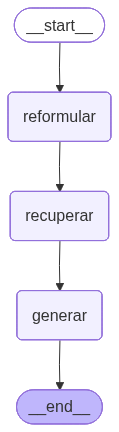


✓ Agente compilado con memoria


In [13]:
grafo = StateGraph(EstadoAgente)

grafo.add_node("reformular", nodo_reformular)
grafo.add_node("recuperar", nodo_recuperar)
grafo.add_node("generar", nodo_generar)

grafo.add_edge(START, "reformular")
grafo.add_edge("reformular", "recuperar")
grafo.add_edge("recuperar", "generar")
grafo.add_edge("generar", END)

memoria = MemorySaver()
agente = grafo.compile(checkpointer=memoria)

# Visualización del grafo
try:
    from IPython.display import Image, display
    display(Image(agente.get_graph().draw_mermaid_png()))
except Exception:
    print(agente.get_graph().draw_ascii())

print("\n✓ Agente compilado con memoria")

---
## PASO 3 — Interacción y ejemplos documentados

In [16]:
# Función de conversación con el agente
def chatear(pregunta: str, thread_id: str = "sesion-01") -> str:
    """Envía una pregunta al agente y devuelve la respuesta."""
    config = {"configurable": {"thread_id": thread_id}}
    resultado = agente.invoke(
        {"mensajes": [HumanMessage(content=pregunta)]},
        config=config,
    )
    return resultado["mensajes"][-1].content

def mostrar_respuesta(pregunta: str, thread_id: str = "sesion-01"):
    """Helper para mostrar pregunta y respuesta con formato."""
    print(f"\n{'='*65}")
    print(f"PREGUNTA: {pregunta}")
    print(f"{'='*65}")
    respuesta = chatear(pregunta, thread_id)
    print(f"\nRESPUESTA:\n{respuesta}")
    return respuesta

print("✓ Funciones de conversación listas")

✓ Funciones de conversación listas


#### 5 ejemplos documentados (mismo thread para demostrar memoria)

In [17]:
THREAD = "demo-ejemplos"

# Ejemplo 1
mostrar_respuesta("¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?", THREAD)


PREGUNTA: ¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?
  [QUERY] Original:    '¿Cuántas empresas textiles hay en España y cómo ha evolucionado este n'
  [QUERY] Reformulada: '¿Cuál es el censo de compañías del sector de la confección y la indust'
  [RAG]   6 chunks recuperados

RESPUESTA:
Según la información proporcionada, el número de empresas en la industria textil y de confección en España ha evolucionado de la siguiente manera:

*   **2017:** 7.823 empresas
*   **2018:** 8.337 empresas
*   **2019:** 8.282 empresas
*   **2020:** 8.119 empresas
*   **2021:** 7.957 empresas
*   **2022:** 7.823 empresas
*   **2023:** 7.600 empresas
*   **2024:** 7.547 empresas

En resumen, tras un pico en 2018, el número de empresas ha mostrado una tendencia a la baja hasta 2024.


'Según la información proporcionada, el número de empresas en la industria textil y de confección en España ha evolucionado de la siguiente manera:\n\n*   **2017:** 7.823 empresas\n*   **2018:** 8.337 empresas\n*   **2019:** 8.282 empresas\n*   **2020:** 8.119 empresas\n*   **2021:** 7.957 empresas\n*   **2022:** 7.823 empresas\n*   **2023:** 7.600 empresas\n*   **2024:** 7.547 empresas\n\nEn resumen, tras un pico en 2018, el número de empresas ha mostrado una tendencia a la baja hasta 2024.'

In [18]:
# Ejemplo 2
mostrar_respuesta("¿Cuál es la estrategia medioambiental de Inditex?", THREAD)


PREGUNTA: ¿Cuál es la estrategia medioambiental de Inditex?
  [QUERY] Original:    '¿Cuál es la estrategia medioambiental de Inditex?'
  [QUERY] Reformulada: '¿Qué políticas de sostenibilidad y responsabilidad social corporativa '
  [RAG]   6 chunks recuperados

RESPUESTA:
La información proporcionada en los documentos no detalla la estrategia medioambiental específica de Inditex. Los textos se centran en aspectos generales de la circularidad textil, ecodiseño, tecnologías de reciclado, el papel de los consumidores y la percepción de la normativa de sostenibilidad en la cadena de valor textil.


'La información proporcionada en los documentos no detalla la estrategia medioambiental específica de Inditex. Los textos se centran en aspectos generales de la circularidad textil, ecodiseño, tecnologías de reciclado, el papel de los consumidores y la percepción de la normativa de sostenibilidad en la cadena de valor textil.'

In [19]:
# Ejemplo 3
mostrar_respuesta("¿Qué es la economía circular aplicada al sector textil?", THREAD)


PREGUNTA: ¿Qué es la economía circular aplicada al sector textil?
  [QUERY] Original:    '¿Qué es la economía circular aplicada al sector textil?'
  [QUERY] Reformulada: '¿Cuál es el modelo de negocio sostenible y regenerativo en la industri'
  [RAG]   6 chunks recuperados

RESPUESTA:
La economía circular aplicada al sector textil se enfoca en transformar el modelo lineal de "tomar-hacer-desechar" hacia un sistema donde los residuos se convierten en recursos, maximizando el ciclo de vida de los productos.

Esto implica:

*   **Prolongar el ciclo de vida de los productos:** A través de servicios como el alquiler, la reparación, la limpieza, el cuidado y la reventa.
*   **Fomentar la longevidad y durabilidad:** Asegurando que las prendas sean física (calidad, funcionalidad, estética) y emocionalmente duraderas.
*   **Reciclaje:** Desarrollando y escalando tecnologías para reciclar materiales textiles, tanto pre-consumo como post-consumo, para reintroducirlos en la cadena de producción.


'La economía circular aplicada al sector textil se enfoca en transformar el modelo lineal de "tomar-hacer-desechar" hacia un sistema donde los residuos se convierten en recursos, maximizando el ciclo de vida de los productos.\n\nEsto implica:\n\n*   **Prolongar el ciclo de vida de los productos:** A través de servicios como el alquiler, la reparación, la limpieza, el cuidado y la reventa.\n*   **Fomentar la longevidad y durabilidad:** Asegurando que las prendas sean física (calidad, funcionalidad, estética) y emocionalmente duraderas.\n*   **Reciclaje:** Desarrollando y escalando tecnologías para reciclar materiales textiles, tanto pre-consumo como post-consumo, para reintroducirlos en la cadena de producción.\n*   **Ecodiseño:** Creando productos que faciliten la circularidad desde su concepción.\n\nEste enfoque busca reducir la generación de residuos, disminuir la dependencia de materias primas vírgenes y transformar la relación entre consumidor y marca, alineándose con los principio

In [20]:
# Ejemplo 4 — referencia al contexto de preguntas anteriores (demuestra memoria)
mostrar_respuesta("¿Y cómo se compara esa estrategia de Inditex con los principios de economía circular que acabas de explicar?", THREAD)


PREGUNTA: ¿Y cómo se compara esa estrategia de Inditex con los principios de economía circular que acabas de explicar?
  [QUERY] Original:    '¿Y cómo se compara esa estrategia de Inditex con los principios de eco'
  [QUERY] Reformulada: '¿Cómo se alinea el modelo de negocio de Inditex con los preceptos de l'
  [RAG]   6 chunks recuperados

RESPUESTA:
La información proporcionada en los documentos no contiene detalles sobre la estrategia medioambiental específica de Inditex. Por lo tanto, no es posible comparar su enfoque con los principios de economía circular que he explicado.


'La información proporcionada en los documentos no contiene detalles sobre la estrategia medioambiental específica de Inditex. Por lo tanto, no es posible comparar su enfoque con los principios de economía circular que he explicado.'

In [21]:
# Ejemplo 5
mostrar_respuesta("¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?", THREAD)


PREGUNTA: ¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?
  [QUERY] Original:    '¿Cuál es la balanza comercial del sector textil en España y qué tenden'
  [QUERY] Reformulada: '¿Cuál es el saldo de la balanza comercial del **sector moda y confecci'
  [RAG]   6 chunks recuperados

RESPUESTA:
La información proporcionada en los documentos indica que el negocio de la moda en su conjunto (incluyendo prendas de vestir, calzado, complementos, cosmética, perfumería, relojería y joyería) sumó exportaciones por valor de **31.664 millones de euros en 2024**. Esta cifra representó el **8,2%** del total de las ventas de bienes de España al exterior durante ese año.

No se proporciona explícitamente el valor de las importaciones ni el cálculo de la balanza comercial (exportaciones menos importaciones) ni su tendencia específica en los extractos facilitados. Sin embargo, se menciona que la cifra de exportación del 8,2% se mantuvo igual que en el ejercicio precede

'La información proporcionada en los documentos indica que el negocio de la moda en su conjunto (incluyendo prendas de vestir, calzado, complementos, cosmética, perfumería, relojería y joyería) sumó exportaciones por valor de **31.664 millones de euros en 2024**. Esta cifra representó el **8,2%** del total de las ventas de bienes de España al exterior durante ese año.\n\nNo se proporciona explícitamente el valor de las importaciones ni el cálculo de la balanza comercial (exportaciones menos importaciones) ni su tendencia específica en los extractos facilitados. Sin embargo, se menciona que la cifra de exportación del 8,2% se mantuvo igual que en el ejercicio precedente, lo que sugiere una estabilidad en la contribución de la moda al total de las exportaciones de bienes.'

---
## PASO 4 — Chat interactivo

Celda de conversación libre con el agente. Ejecuta y escribe tu pregunta cuando aparezca el prompt.

In [17]:
# Celda interactiva — escribe 'salir' para terminar
THREAD_CHAT = "chat-interactivo"
print("Agente Textil España — escribe 'salir' para terminar\n")

while True:
    pregunta = input("Tú: ").strip()
    if not pregunta:
        continue
    if pregunta.lower() in ("salir", "exit", "quit"):
        print("Conversación finalizada.")
        break
    respuesta = chatear(pregunta, THREAD_CHAT)
    print(f"\nAgente: {respuesta}\n")

Agente Textil España — escribe 'salir' para terminar

Conversación finalizada.
